In [ ]:
import pandas as pd

# Define the path to your metadata.csv file. Make sure this path is correct.
# Based on our previous conversation, it's likely '/content/sample_data/metadata.csv'
file_path = '/content/sample_data/metadata.csv'

# Load the metadata.csv file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"\nSuccessfully loaded '{file_path}' into a DataFrame.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
    df = None # Set df to None to indicate failure
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    df = None

if df is not None:
    print("\n--- First 5 rows of the DataFrame ---")
    print(df.head())

    print("\n--- DataFrame Dimensions (Rows, Columns) ---")
    print(df.shape)

    print("\n--- DataFrame Information (Data Types, Non-Null Counts) ---")
    df.info()

    print("\n--- Descriptive Statistics for Numerical Columns ---")
    print(df.describe())


Successfully loaded '/content/sample_data/metadata.csv' into a DataFrame.

--- First 5 rows of the DataFrame ---
   cord_uid                                       sha source_x  \
0  ug7v899j  d1aafb70c066a2068b02786f8929fd9c900897fb      PMC   
1  02tnwd4m  6b0567729c2143a66d737eb0a2f63f2dce2e5a7d      PMC   
2  ejv2xln0  06ced00a5fc04215949aa72528f2eeaae1d58927      PMC   
3  2b73a28n  348055649b6b8cf2b9a376498df9bf41f7123605      PMC   
4  9785vg6d  5f48792a5fa08bed9f56016f4981ae2ca6031b32      PMC   

                                               title                    doi  \
0  Clinical features of culture-proven Mycoplasma...  10.1186/1471-2334-1-6   
1  Nitric oxide: a pro-inflammatory mediator in l...           10.1186/rr14   
2    Surfactant protein-D and pulmonary host defense           10.1186/rr19   
3               Role of endothelin-1 in lung disease           10.1186/rr44   
4  Gene expression in epithelial cells in respons...           10.1186/rr61   

      pmcid pu

/tmp/ipython-input-1818971914.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
if df is not None:
    print("\n--- Checking for Missing Values ---")
    print(df.isnull().sum())
else:
    print("DataFrame is not loaded. Please ensure the previous step ran successfully.")

In [ ]:
import pandas as pd
import numpy as np

if df is not None:
    print("\n--- Data Cleaning and Preparation ---")

    # 1. Dropped columns with too many missing values
    columns_to_drop = ['mag_id', 'who_covidence_id', 'arxiv_id', 's2_id']
    df_cleaned = df.drop(columns=columns_to_drop, errors='ignore') 
    print(f"Dropped columns with high missing values: {columns_to_drop}")

    # 2. Handle missing values in important text columns
    df_cleaned['title'].fillna('[No Title]', inplace=True)

    # Filled missing abstracts with '[No Abstract]' to allow for text processing without errors
    df_cleaned['abstract'].fillna('[No Abstract]', inplace=True)

    # Filled missing authors and journal names
    df_cleaned['authors'].fillna('[No Authors]', inplace=True)
    df_cleaned['journal'].fillna('[No Journal]', inplace=True)

    print("Filled missing values in 'title', 'abstract', 'authors', and 'journal'.")

    # 3. Converted 'publish_time' to datetime and extract year
    df_cleaned['publish_time'] = pd.to_datetime(df_cleaned['publish_time'], errors='coerce')

    # Dropped rows where 'publish_time' could not be parsed 
    df_cleaned.dropna(subset=['publish_time'], inplace=True)
    print("Converted 'publish_time' to datetime and dropped unparseable entries.")

    # Extracted publication year
    df_cleaned['publish_year'] = df_cleaned['publish_time'].dt.year
    print("Extracted 'publish_year' from 'publish_time'.")

    # 4. Created abstract word count column
    df_cleaned['abstract_word_count'] = df_cleaned['abstract'].apply(lambda x: len(str(x).split()))
    print("Created 'abstract_word_count' column.")

    print("\n--- Cleaned DataFrame Info ---")
    df_cleaned.info()

    print("\n--- First 5 rows of Cleaned DataFrame ---")
    print(df_cleaned.head())

    
    df = df_cleaned.copy()
else:
    print("DataFrame is not loaded. Please ensure previous steps ran successfully.")


--- Data Cleaning and Preparation ---
Dropped columns with high missing values: ['mag_id', 'who_covidence_id', 'arxiv_id', 's2_id']
Filled missing values in 'title', 'abstract', 'authors', and 'journal'.
Converted 'publish_time' to datetime and dropped unparseable entries.
Extracted 'publish_year' from 'publish_time'.


/tmp/ipython-input-1356498176.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['title'].fillna('[No Title]', inplace=True)
/tmp/ipython-input-1356498176.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Created 'abstract_word_count' column.

--- Cleaned DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 61772 entries, 0 to 64273
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cord_uid             61772 non-null  object        
 1   sha                  46946 non-null  object        
 2   source_x             61772 non-null  object        
 3   title                61772 non-null  object        
 4   doi                  61772 non-null  object        
 5   pmcid                61772 non-null  object        
 6   pubmed_id            32161 non-null  object        
 7   license              61772 non-null  object        
 8   abstract             61772 non-null  object        
 9   publish_time         61772 non-null  datetime64[ns]
 10  authors              61772 non-null  object        
 11  journal              61772 non-null  object        
 12  pdf_json_files       46

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import re

if df is not None:
    print("\n--- Data Analysis ---")

    # 1. Count papers by publication year
    papers_by_year = df['publish_year'].value_counts().sort_index()
    print("\n--- Papers by Publication Year ---")
    print(papers_by_year.head())
    print(papers_by_year.tail())

    # 2.  top journals publishing COVID-19 research
    top_journals = df['journal'].value_counts().head(10)
    print("\n--- Top 10 Publishing Journals ---")
    print(top_journals)


    all_titles = ' '.join(df['title'].str.lower().tolist())


    words = re.findall(r'\b[a-z]+\b', all_titles)


    stopwords = set([
        'the', 'and', 'to', 'of', 'a', 'in', 'for', 'on', 'with', 'as', 'by', 'at', 'from',
        'is', 'are', 'was', 'were', 'be', 'an', 'or', 'that', 'this', 'it', 'has', 'have',
        'which', 'can', 'may', 'new', 'study', 'report', 'review', 'case', 'based', 'data',
        'results', 'analysis', 'impact', 'effect', 'clinical', 'patients', 'novel', 'associated',
        'risk', 'from', 'disease', 'health', 'respiratory', 'syndrome', 'acute', 'severe'
    ])

    # Filtered  stopwords and single-letter words
    filtered_words = [word for word in words if word not in stopwords and len(word) > 1]

    # Count word frequencies
    word_counts = Counter(filtered_words)
    most_common_words = word_counts.most_common(20)

    print("\n--- 20 Most Frequent Words in Titles ---")
    for word, count in most_common_words:
        print(f"{word}: {count}")

else:
    print("DataFrame is not loaded. Please ensure previous steps ran successfully.")



--- Data Analysis ---

--- Papers by Publication Year ---
publish_year
1957    1
1962    1
1964    2
1968    1
1969    2
Name: count, dtype: int64
publish_year
2018     1348
2019     1951
2020    19117
2021    17682
2022     6875
Name: count, dtype: int64

--- Top 10 Publishing Journals ---
journal
[No Journal]                                               3352
PLoS One                                                   1370
Reactions Weekly                                           1187
Sci Rep                                                     886
Int J Environ Res Public Health                             738
Computational Science and Its Applications - ICCSA 2020     500
Nat Commun                                                  473
Lancet                                                      459
Int J Mol Sci                                               456
Open Forum Infect Dis                                       450
Name: count, dtype: int64

--- 20 Most Frequent Words in Ti


--- Generating Visualizations ---


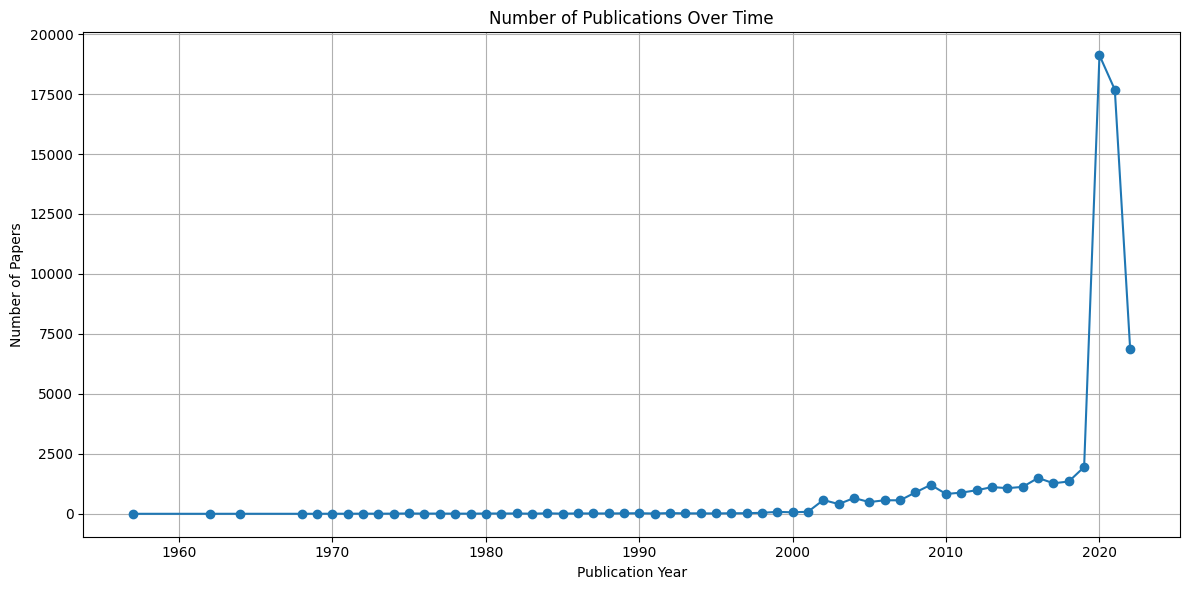

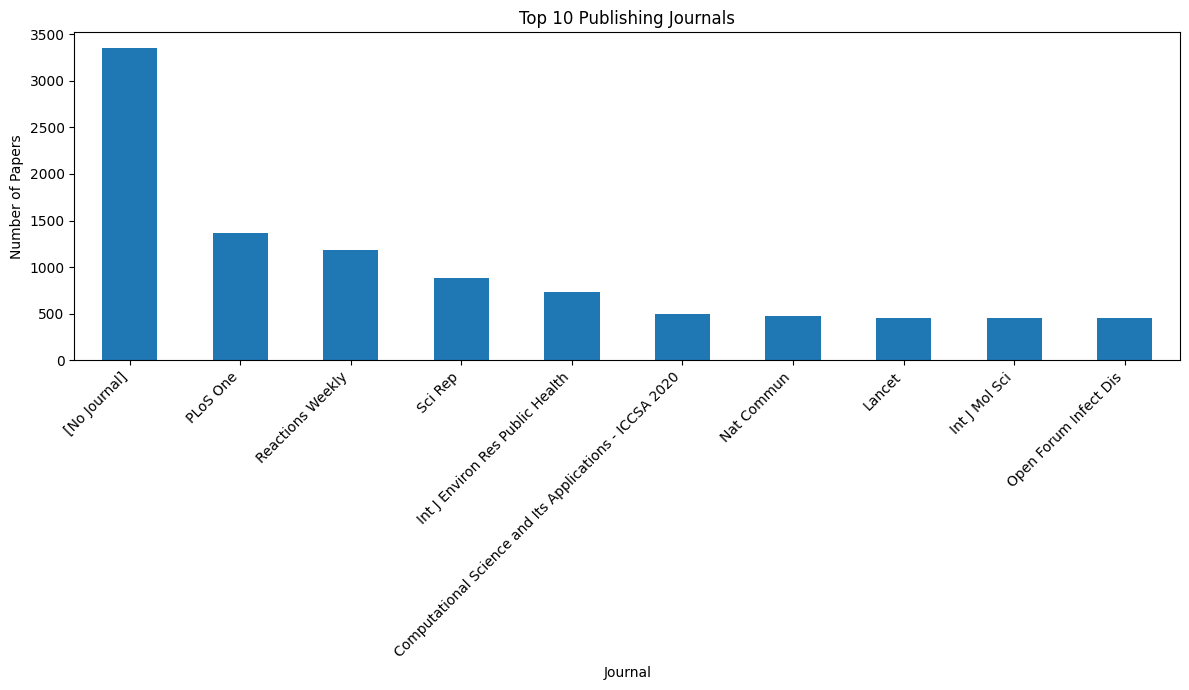

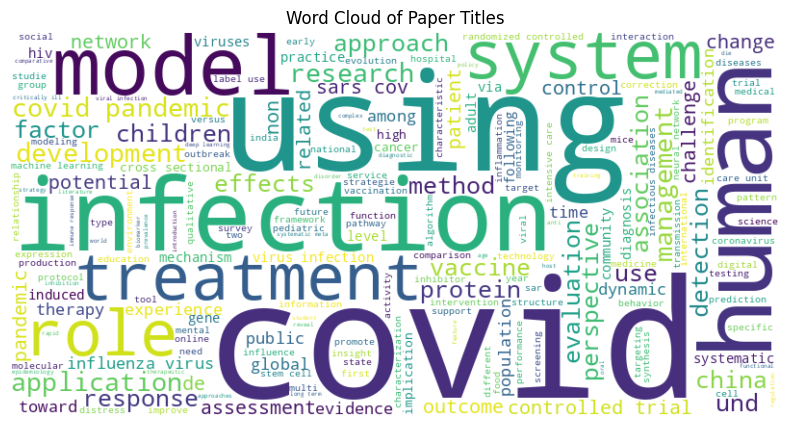

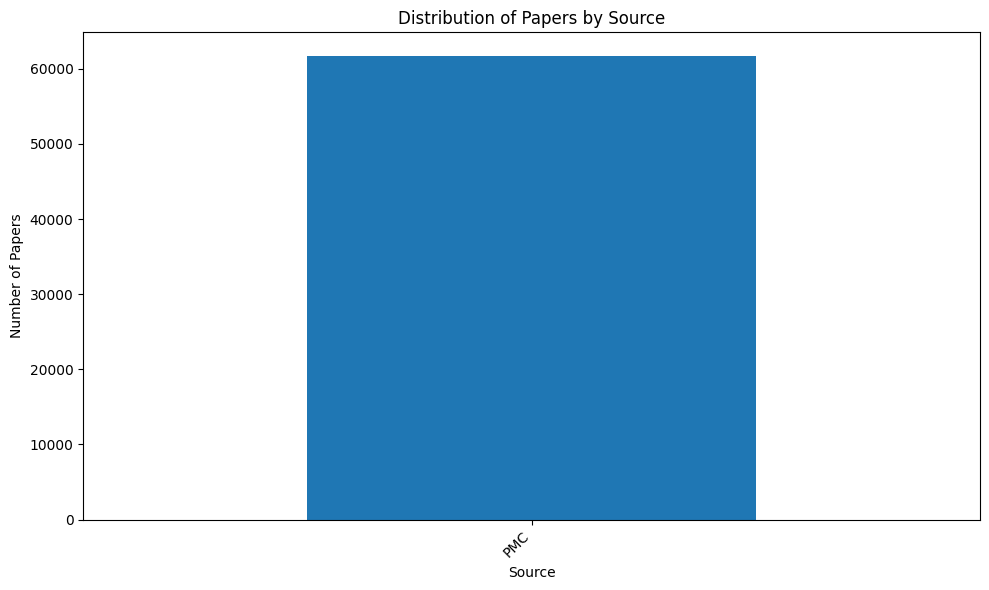

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd 
from collections import Counter 
import re 

if df is not None:
    print("\n--- Generating Visualizations ---")

    # 1. Plot number of publications over time
    plt.figure(figsize=(12, 6))
    df['publish_year'].value_counts().sort_index().plot(kind='line', marker='o')
    plt.title('Number of Publications Over Time')
    plt.xlabel('Publication Year')
    plt.ylabel('Number of Papers')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2.  a bar chart of top publishing journals
    plt.figure(figsize=(12, 7))
    df['journal'].value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 Publishing Journals')
    plt.xlabel('Journal')
    plt.ylabel('Number of Papers')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 3.  A word cloud of paper titles
    all_titles_for_wc = ' '.join(df['title'].str.lower().tolist())
    words_for_wc = re.findall(r'\b[a-z]+\b', all_titles_for_wc)
    stopwords_for_wc = set([
        'the', 'and', 'to', 'of', 'a', 'in', 'for', 'on', 'with', 'as', 'by', 'at', 'from',
        'is', 'are', 'was', 'were', 'be', 'an', 'or', 'that', 'this', 'it', 'has', 'have',
        'which', 'can', 'may', 'new', 'study', 'report', 'review', 'case', 'based', 'data',
        'results', 'analysis', 'impact', 'effect', 'clinical', 'patients', 'novel', 'associated',
        'risk', 'from', 'disease', 'health', 'respiratory', 'syndrome', 'acute', 'severe'
    ])
    filtered_words_for_wc = [word for word in words_for_wc if word not in stopwords_for_wc and len(word) > 1]

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(filtered_words_for_wc))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Paper Titles')
    plt.show()

    # 4. Plot distribution of paper counts by source
    plt.figure(figsize=(10, 6))
    df['source_x'].value_counts().plot(kind='bar')
    plt.title('Distribution of Papers by Source')
    plt.xlabel('Source')
    plt.ylabel('Number of Papers')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("DataFrame is not loaded. Please ensure previous steps ran successfully.")